In [43]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import skimage.measure
from skimage.measure import label

In [1]:
image_path = '/home/projects/registration/athira/mytest/sample_data/original_image/B_141-ST_BFI-SE_1411_original.jpg'
bgr_image = cv.imread(image_path) #original image, cv.imread reads in bgr format
print(bgr_image.shape)
rgb_image = cv.cvtColor(bgr_image, cv.COLOR_BGR2RGB) #BGR to RGB conversion since while using imshow it uses rgb format
bgr_image_transpose = np.transpose(bgr_image, axes=[1,0,2]) #taking transpose of original bgr image and using it for further processing
plt.imshow(rgb_image, cmap='gray')
#plt.imshow(bgr_image_transpose)

# Axis 0: Height (rows)
# Axis 1: Width (columns)
# Axis 2: Color channels (BGR or RGB)

NameError: name 'cv' is not defined

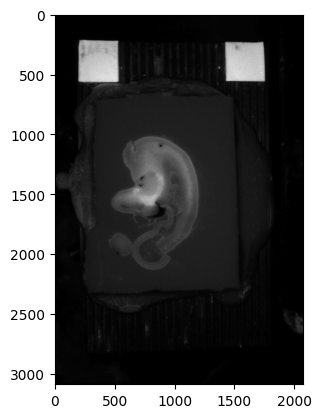

In [35]:
# converting bgr to Ycbcr
# converts the image bgr_image_transpose from BGR color space to YCrCb color space
ycbcr_image = cv.cvtColor(bgr_image_transpose, cv.COLOR_BGR2YCrCb) 
gray_image = ycbcr_image[:,:,0]  # selecting all rows and columns & extracts the Y channel
plt.imshow(gray_image, cmap = 'gray')

# # Extract the Y channel (luma)
# y_channel = ycbcr_image[:,:,0]
# # Extract the Cr channel (chroma red-difference)
#cr_channel = ycbcr_image[:,:,1]
#plt.imshow(cr_channel , cmap = 'gray')
# # Extract the Cb channel (chroma blue-difference)
# cb_channel = ycbcr_image[:,:,2]

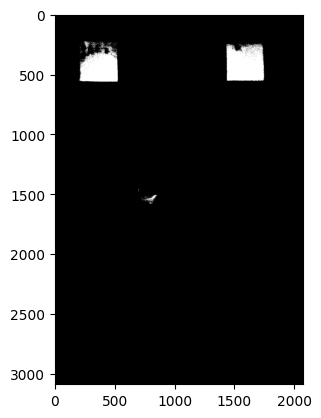

In [36]:
thres = np.max(gray_image) - 0.3*(np.max(gray_image))
ret, thresh1 = cv.threshold(gray_image, thres,np.max(gray_image), cv.THRESH_BINARY) # binary threshold
plt.imshow(thresh1, cmap='gray')

# np.max(gray_image): returns the maximum pixel value in the gray_image
# np.max(gray_image) - 0.3*(np.max(gray_image)): This expression calculates a threshold value that is 30% less than the 
# maximum pixel value in the gray_image ie,= 0.7×max_val

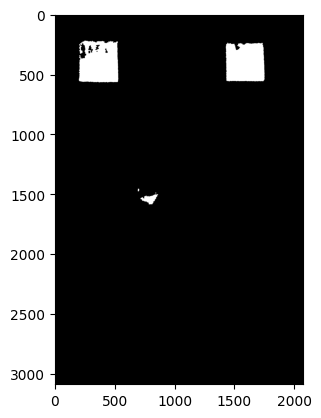

In [37]:
#Step2 : Dilate it by square structural element kernel (7,7), also perform morphological close operation
element = cv.getStructuringElement(cv.MORPH_RECT, (7,7)) # creates a rectangular structuring element (kernel) of size 7x7
dilate1 = cv.dilate(thresh1, element, iterations = 1) # Dilation adds pixels to the boundaries, =1 means dilation operation is performed

kernel = np.ones((7, 7), np.uint8) # Adjust the kernel size as needed
mask_image_closed = cv.morphologyEx(dilate1, cv.MORPH_CLOSE, kernel) # used to close small holes or gaps in the object
plt.imshow(mask_image_closed , cmap='gray') 

Number of labels in /home/projects/registration/athira/mytest/sample_data/original_image/B_141-ST_BFI-SE_1002_original.jpg: 5
100782.0
97435.0
230.0
56.0
6381.0
Top 2 regions by area:
Region 1 - Area: 100782.0
Region 2 - Area: 97435.0


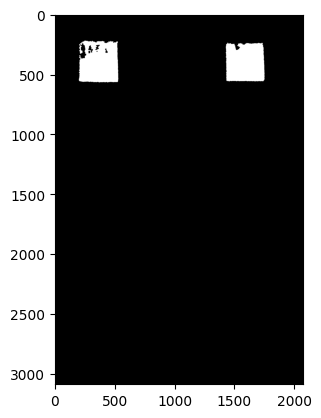

In [38]:
#Step3 : Use region properties, pixel count/ area; sort the areas based on area/pixel count, get the top 2 areas
# Label the connected components in the mask-------method 1
# skimage.measure.label : labels connected regions in a binary image
# connectivity=2 : pixels are connected if they share a face, edge, or corner
labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
print(f"Number of labels in {image_path}: {count}")
regions = skimage.measure.regionprops(labeled_image)
for prop in regions:
    print(prop.area)

# sort and get top 2 maximum area 
# Sort regions by area in descending order
regions.sort(key=lambda x: x.area, reverse=True)

# Print areas of the top 2 regions
print("Top 2 regions by area:")
for i in range(min(2, len(regions))):  # Ensure we only print up to top 2 regions
    print(f"Region {i + 1} - Area: {regions[i].area}")

# Create an image containing only the top 2 regions by area
top_regions = np.zeros_like(labeled_image) # empty image (all zeros) with the same shape as the labeled image.
for i in range(min(2, len(regions))):  # Ensure we only select up to top 2 regions
    top_regions[labeled_image == regions[i].label] = 1

plt.imshow(top_regions, cmap='gray')

(198217, 1, 2)


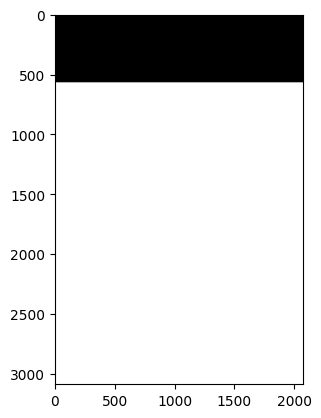

In [39]:
#Step7 : Get largest X index, blackwhite , negate : 1 - blackwhite = mask
pixelpointsCV_fid = cv.findNonZero(top_regions) # finds all non-zero points (pixels) in a binary image (masked_image).

print(pixelpointsCV_fid.shape) # (N, 1, 2), where N is the number of non-zero pixels
x_indices = pixelpointsCV_fid[:,0,1] # extracts the y-coordinates (row indices) of the non-zero pixels
new_mask = np.zeros(top_regions.shape)
new_mask[0:np.max(x_indices),:]=1
#plt.imshow(new_mask, cmap='gray' )
plt.imshow(1-new_mask, cmap='gray')

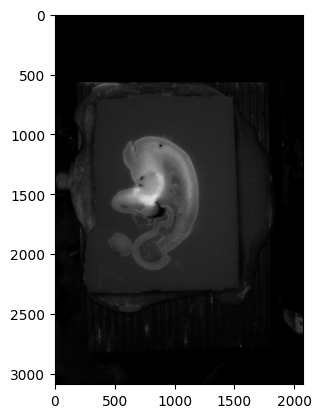

In [40]:
#Step8: ElementWise multiply mask for original section
new_original_image = np.multiply(gray_image,1-new_mask) 
plt.imshow(new_original_image, cmap='gray')

In [41]:
# Apply the same mask to Cr and Cb channels and set neutral values to 128 where new_mask =1
ycbcr_image[:,:,1] = np.where(new_mask == 1, 128, ycbcr_image[:,:,1])
ycbcr_image[:,:,2] = np.where(new_mask == 1, 128, ycbcr_image[:,:,2])
ycbcr_image[:,:,0] = new_original_image

(2076, 3088, 3)


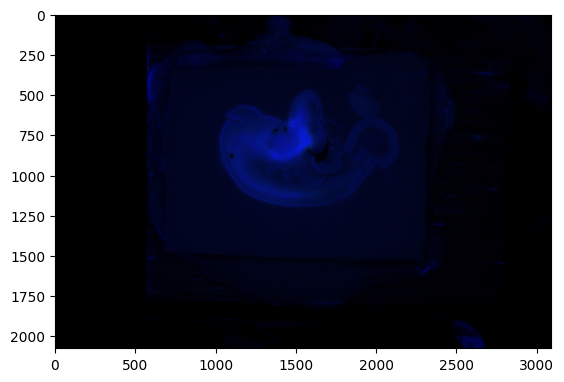

In [42]:
new_bgr_image = cv.cvtColor(ycbcr_image, cv.COLOR_YCrCb2BGR)
output_bgr_image_transpose = np.transpose(new_bgr_image, axes=[1,0,2])
print(output_bgr_image_transpose.shape)
plt.imshow(cv.cvtColor(output_bgr_image_transpose, cv.COLOR_BGR2RGB)) #to show in plot we change bgr2rgb only for view purpose

In [ ]:
#WRITING ABOVE PROGRAM AS A FUNCTION

shape of input image is: (2076, 3088, 3)
Top 2 regions by area:
Region 1 - Area: 104260.0
Region 2 - Area: 98883.0
shape of final feducial removed image is: (2076, 3088, 3)


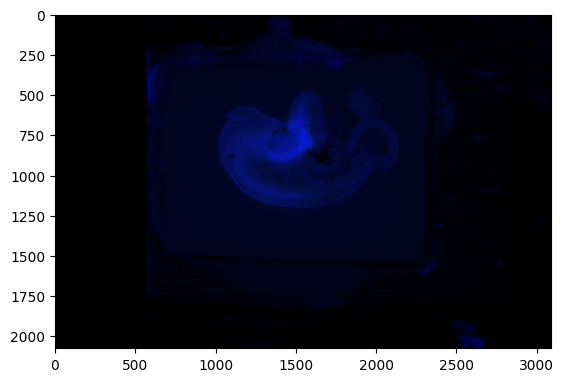

In [28]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import skimage.measure
from skimage.measure import label

image_path = '/home/projects/registration/athira/mytest/sample_data/B_141-ST_BFI-SE_1003_original.jpg'
bgr_image = cv.imread(image_path) #original image, cv.imread reads in bgr format
print('shape of input image is:', bgr_image.shape)
bgr_image_transpose = np.transpose(bgr_image, axes=[1,0,2]) #taking transpose of original bgr image and using it for further processing

# converting bgr to Ycbcr
ycbcr_image = cv.cvtColor(bgr_image_transpose, cv.COLOR_BGR2YCrCb)
gray_image = ycbcr_image[:,:,0]

thres = np.max(gray_image) - 0.3*(np.max(gray_image))
ret, thresh1 = cv.threshold(gray_image, thres,np.max(gray_image), cv.THRESH_BINARY)

#Step2 : Dilate it by square structural element kernel (7,7), also perform morphological close operation
element = cv.getStructuringElement(cv.MORPH_RECT, (7,7))
dilate1 = cv.dilate(thresh1, element, iterations = 1)
kernel = np.ones((7, 7), np.uint8)  # Adjust the kernel size as needed
mask_image_closed = cv.morphologyEx(dilate1, cv.MORPH_CLOSE, kernel)

#Step3 : Use region properties, pixel count/ area; sort the areas based on area/pixel count, get the top 2 areas
# Label the connected components in the mask-------method 1
labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
regions = skimage.measure.regionprops(labeled_image)

#sort and get top 2 maximum area # Sort regions by area in descending order
regions.sort(key=lambda x: x.area, reverse=True)
# Print areas of the top 2 regions
print("Top 2 regions by area:")
for i in range(min(2, len(regions))):  # Ensure we only print up to top 2 regions
    print(f"Region {i + 1} - Area: {regions[i].area}")

# Create an image containing only the top 2 regions by area
top_regions = np.zeros_like(labeled_image)
for i in range(min(2, len(regions))):  # Ensure we only select up to top 2 regions
    top_regions[labeled_image == regions[i].label] = 1


#Step7 : Get largest X index, blackwhite , negate : 1 - blackwhite = mask
pixelpointsCV_fid = cv.findNonZero(top_regions) # finds all non-zero points (pixels) in a binary image (masked_image).
x_indices = pixelpointsCV_fid[:,0,1]
new_mask = np.zeros(top_regions.shape)
new_mask[0:np.max(x_indices),:]=1

#Step8: ElementWise multiply mask for original section
new_original_image = np.multiply(gray_image,1-new_mask) 

# Apply the same mask to Cr and Cb channels and set neutral values where masked
ycbcr_image[:,:,1] = np.where(new_mask == 1, 128, ycbcr_image[:,:,1])
ycbcr_image[:,:,2] = np.where(new_mask == 1, 128, ycbcr_image[:,:,2])
ycbcr_image[:,:,0] = new_original_image

new_bgr_image = cv.cvtColor(ycbcr_image, cv.COLOR_YCrCb2BGR)
output_bgr_image_transpose = np.transpose(new_bgr_image, axes=[1,0,2])
print('shape of final feducial removed image is:', output_bgr_image_transpose.shape)
plt.imshow(cv.cvtColor(output_bgr_image_transpose, cv.COLOR_BGR2RGB)) #to show in plot we change bgr2rgb only for view purpose


Shape of input image is: (2076, 3088, 3)
Top 2 regions by area:
Region 1 - Area: 104260.0
Region 2 - Area: 98883.0
Shape of final fiducial removed image is: (2076, 3088, 3)


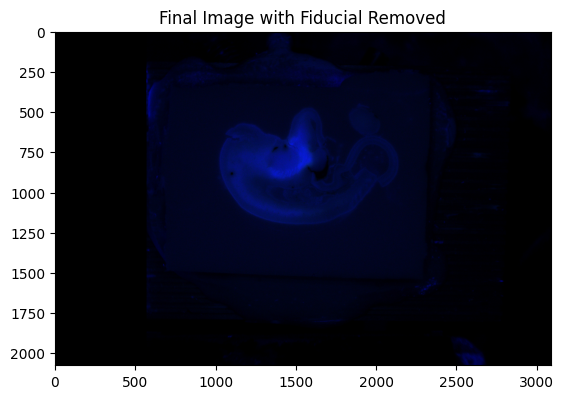

In [31]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import skimage.measure
from skimage.measure import label

def process_image(image_path):
    # Step 1: Load and transpose the image
    bgr_image = cv.imread(image_path)
    print('Shape of input image is:', bgr_image.shape)
    bgr_image_transpose = np.transpose(bgr_image, axes=[1,0,2])  # Transpose the original BGR image

    # Step 2: Convert BGR to YCbCr
    ycbcr_image = cv.cvtColor(bgr_image_transpose, cv.COLOR_BGR2YCrCb)
    gray_image = ycbcr_image[:,:,0]

    # Step 3: Thresholding
    thres = np.max(gray_image) - 0.3 * (np.max(gray_image))
    ret, thresh1 = cv.threshold(gray_image, thres, np.max(gray_image), cv.THRESH_BINARY)

    # Step 4: Dilation and morphological closing
    element = cv.getStructuringElement(cv.MORPH_RECT, (7,7))
    dilate1 = cv.dilate(thresh1, element, iterations=1)
    kernel = np.ones((7, 7), np.uint8)
    mask_image_closed = cv.morphologyEx(dilate1, cv.MORPH_CLOSE, kernel)

    # Step 5: Label connected components and sort by area
    labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
    regions = skimage.measure.regionprops(labeled_image)
    regions.sort(key=lambda x: x.area, reverse=True)
    print("Top 2 regions by area:")
    for i in range(min(2, len(regions))):
        print(f"Region {i + 1} - Area: {regions[i].area}")

    # Step 6: Create an image containing only the top 2 regions by area
    top_regions = np.zeros_like(labeled_image)
    for i in range(min(2, len(regions))):
        top_regions[labeled_image == regions[i].label] = 1

    # Step 7: Get largest X index and create a new mask
    pixelpointsCV_fid = cv.findNonZero(top_regions)
    x_indices = pixelpointsCV_fid[:,0,1]
    new_mask = np.zeros(top_regions.shape)
    new_mask[0:np.max(x_indices),:] = 1

    # Step 8: Element-wise multiply mask for the original section
    new_original_image = np.multiply(gray_image, 1-new_mask)
    
    # Apply the same mask to Cr and Cb channels and set neutral values where masked
    ycbcr_image[:,:,1] = np.where(new_mask == 1, 128, ycbcr_image[:,:,1])
    ycbcr_image[:,:,2] = np.where(new_mask == 1, 128, ycbcr_image[:,:,2])
    ycbcr_image[:,:,0] = new_original_image

    # Convert back to BGR
    new_bgr_image = cv.cvtColor(ycbcr_image, cv.COLOR_YCrCb2BGR)
    output_bgr_image_transpose = np.transpose(new_bgr_image, axes=[1,0,2])
    print('Shape of final fiducial removed image is:', output_bgr_image_transpose.shape)

    # Display the final image
    plt.imshow(cv.cvtColor(output_bgr_image_transpose, cv.COLOR_BGR2RGB))
    plt.title('Final Image with Fiducial Removed')
    plt.show()
    
    return output_bgr_image_transpose

# Example usage
image_path = '/home/projects/registration/athira/mytest/sample_data/B_141-ST_BFI-SE_1003_original.jpg'
final_image = process_image(image_path)


In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import skimage.measure
from skimage.measure import label

def process_image(image_path):
    # Step 1: Load and transpose the image
    bgr_image = cv.imread(image_path)
    bgr_image_transpose = np.transpose(bgr_image, axes=[1,0,2])  # Transpose the original BGR image

    # Step 2: Convert BGR to YCbCr
    ycbcr_image = cv.cvtColor(bgr_image_transpose, cv.COLOR_BGR2YCrCb)
    gray_image = ycbcr_image[:,:,0]

    # Step 3: Thresholding
    thres = np.max(gray_image) - 0.3 * (np.max(gray_image))
    ret, thresh1 = cv.threshold(gray_image, thres, np.max(gray_image), cv.THRESH_BINARY)

    # Step 4: Dilation and morphological closing
    element = cv.getStructuringElement(cv.MORPH_RECT, (7,7))
    dilate1 = cv.dilate(thresh1, element, iterations=1)
    kernel = np.ones((7, 7), np.uint8)
    mask_image_closed = cv.morphologyEx(dilate1, cv.MORPH_CLOSE, kernel)

    # Step 5: Label connected components and sort by area
    labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
    regions = skimage.measure.regionprops(labeled_image)
    regions.sort(key=lambda x: x.area, reverse=True)
    print("Top 2 regions by area:")
    for i in range(min(2, len(regions))):
        print(f"Region {i + 1} - Area: {regions[i].area}")

    # Step 6: Create an image containing only the top 2 regions by area
    top_regions = np.zeros_like(labeled_image)
    for i in range(min(2, len(regions))):
        top_regions[labeled_image == regions[i].label] = 1

    # Step 7: Get largest X index and create a new mask
    pixelpointsCV_fid = cv.findNonZero(top_regions)
    x_indices = pixelpointsCV_fid[:,0,1]
    new_mask = np.zeros(top_regions.shape)
    new_mask[0:np.max(x_indices),:] = 1

    # Step 8: Element-wise multiply mask for the original section
    new_original_image = np.multiply(gray_image, 1-new_mask)
    
    # Apply the same mask to Cr and Cb channels and set neutral values where masked
    ycbcr_image[:,:,1] = np.where(new_mask == 1, 128, ycbcr_image[:,:,1])
    ycbcr_image[:,:,2] = np.where(new_mask == 1, 128, ycbcr_image[:,:,2])
    ycbcr_image[:,:,0] = new_original_image

    # Convert back to BGR
    new_bgr_image = cv.cvtColor(ycbcr_image, cv.COLOR_YCrCb2BGR)
    output_bgr_image_transpose = np.transpose(new_bgr_image, axes=[1,0,2])
    
    return output_bgr_image_transpose

# Example usage
image_path = '/home/projects/registration/athira/mytest/sample_data/B_141-ST_BFI-SE_1003_original.jpg'
final_image = process_image(image_path)


Top 2 regions by area:
Region 1 - Area: 104260.0
Region 2 - Area: 98883.0
